In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, generate_uniform_points_in_simplex, addWGN, ProjectColstoSimplex
from bss.CorInfoMaxBSS import OnlineCorInfomax

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -4, max_val = 4)
S = ProjectColstoSimplex(S)

print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 15
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  2797252
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 14.990791889466186


(array([0.12406999, 0.12405327, 0.12409555, 0.12440645, 0.12407021]),
 array([0.804278  , 0.41019775, 1.1037028 , 0.84233086, 0.23280514,
        0.55665329, 0.20646014, 0.73781044, 0.85306963, 1.88504341]))

# Hyperparameters

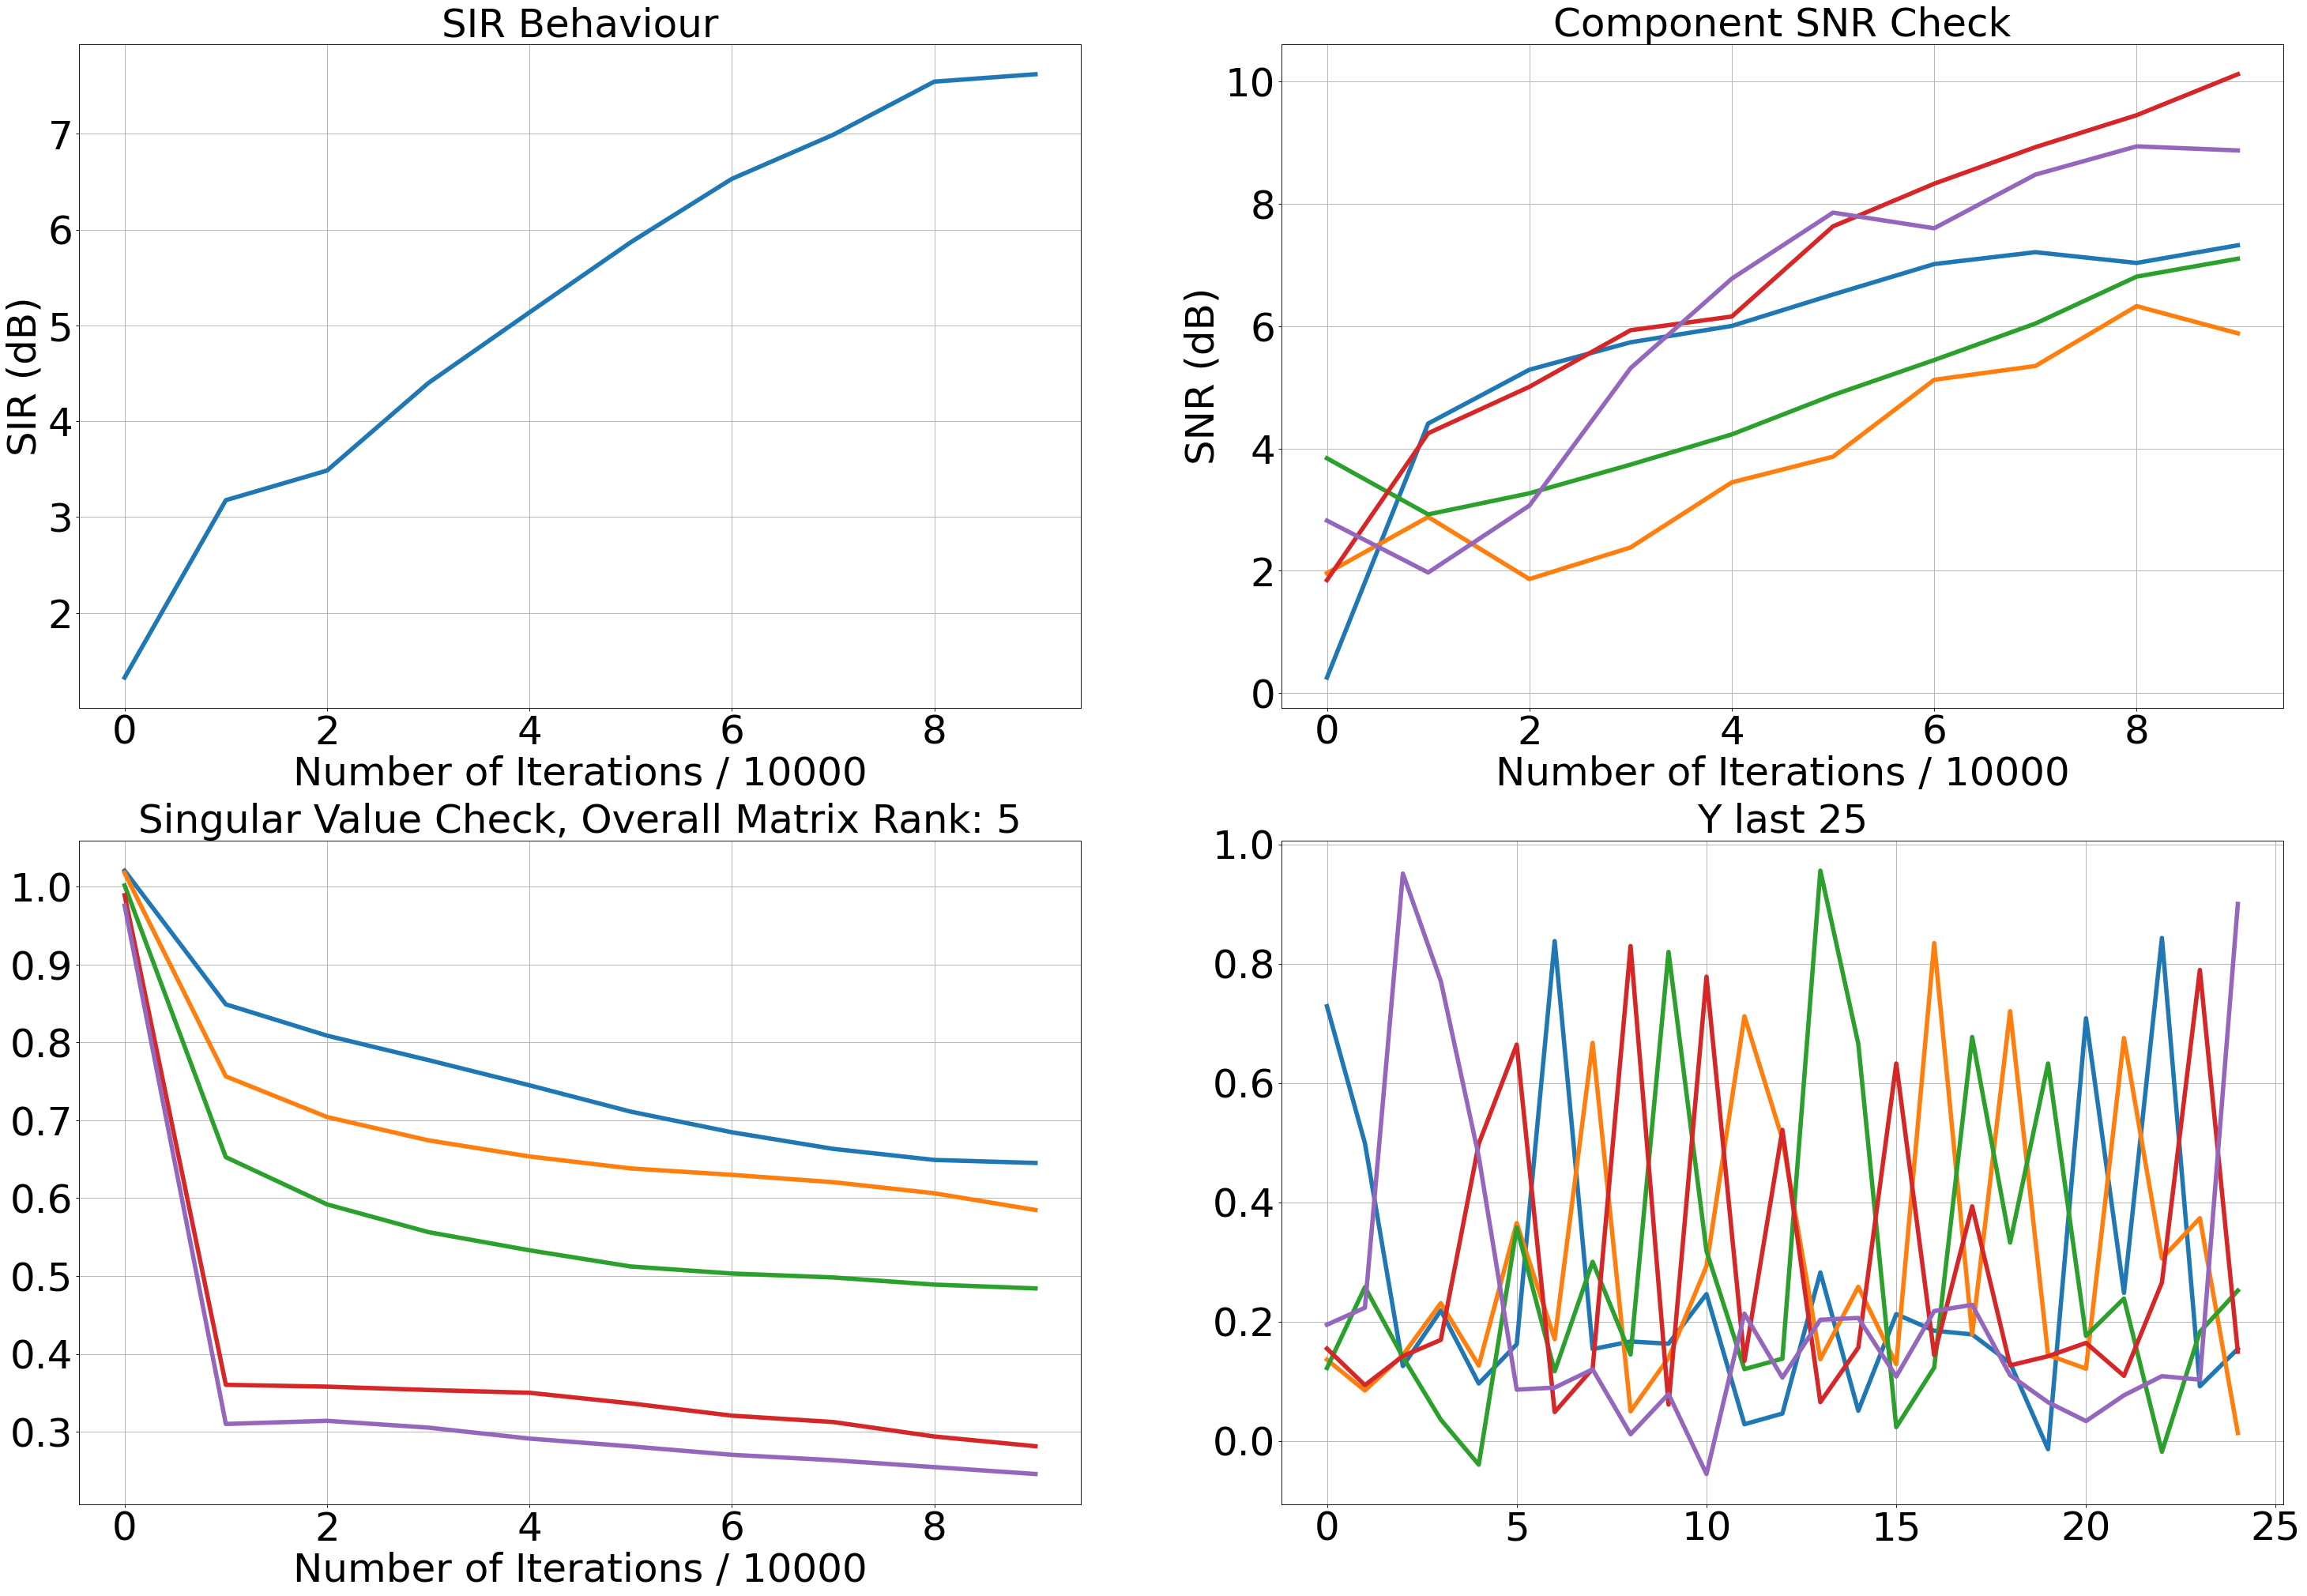

100%|██████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:01<00:00, 1620.37it/s]


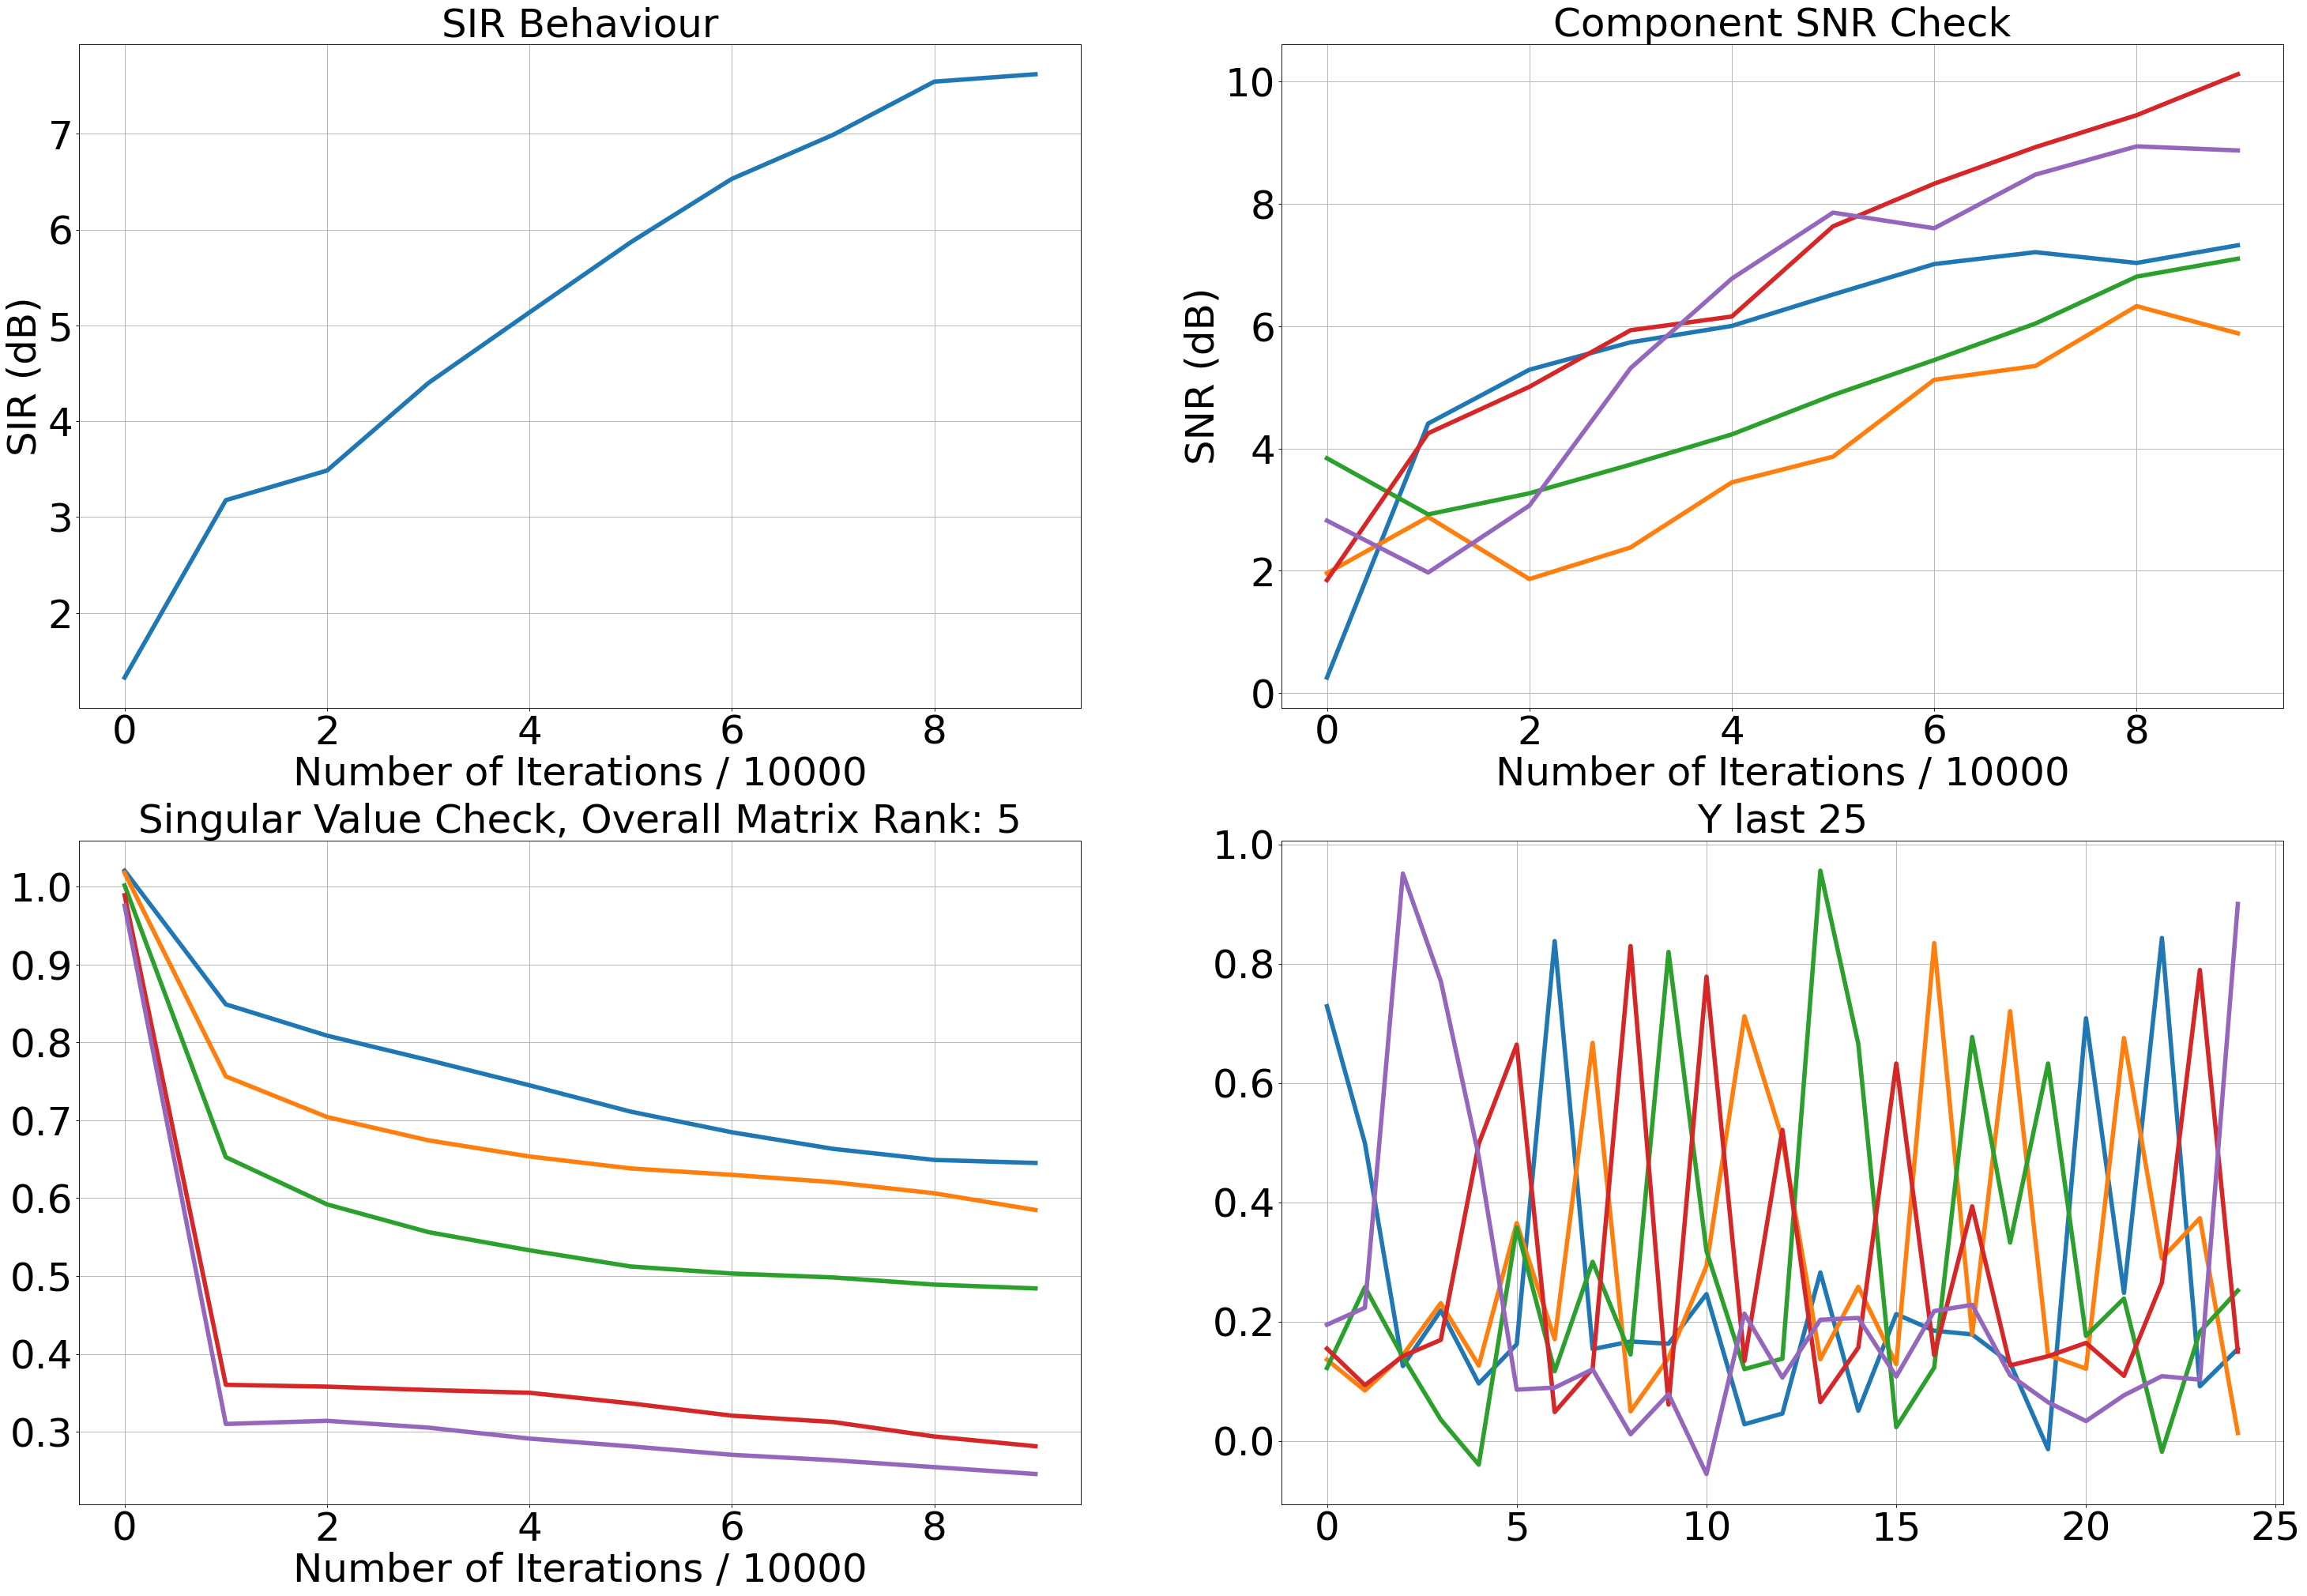

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "simplex",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 50,
                ### Learning rates 
                "lr_W" : 1 * 1e-2,
                "neural_lr_start" : 0.1,
                "neural_lr_stop" : 1e-3,
                "stlambda_lr" : 0.05,
                "neural_dynamics_iterations" : 500,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "constant",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 100,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "B_y" : 1*np.eye(NumberofSources),
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = OnlineCorInfomax(**hyperparam_dict)
model.fit(X)

In [4]:
display_matrix(model.B_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [6]:
Wf = np.linalg.solve(model.gamy * model.B_y - model.gamma_predictive * np.eye(NumberofSources), model.gamma_predictive * model.W)
display_matrix(Wf)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = Wf @ X
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 7.387448159193672
Component Signal-to-Noise-Ratio (SNR) Values : [ 7.75633372  6.77391205  7.27613194 10.51569229  9.28043479]



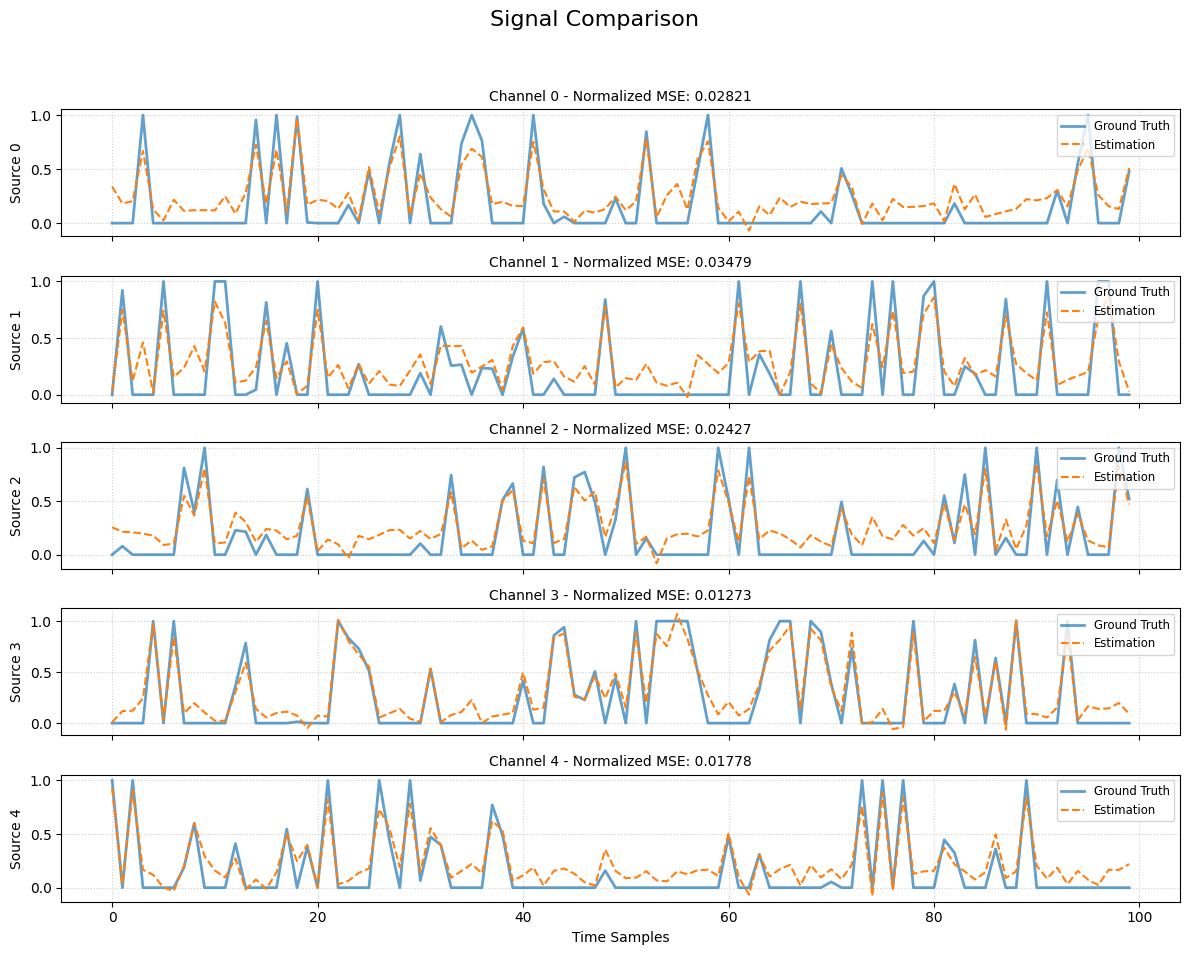

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])